In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import src.pfr as pfr
import src.cstr as cstr

# Apendice (Sesión 03)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño


2025

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# Ejemplos de implementación

In [2]:
k = 0.1     # Reaction rate constant (1/min)
V_total = 100.0  # Total volume of the reactors (L)
Q = 10.0        # Volumetric flow rate (L/min)
C_in = 1.0    # Initial concentration of A (mol/L)
order = 1.0

## Conversión CSTR

### CSTR en serie

Efecto del número de reactores CSTR en serie sobre la conversión total, para un volumen total de reactor(es) fijo:

- Para un volumen total fijo, el número de reactores CSTR es directamente proporcional a la conversión.

- Cuando el número de reactores tiende a infinito, la conversión tiende a aquella que se puede lograr en un PFR.

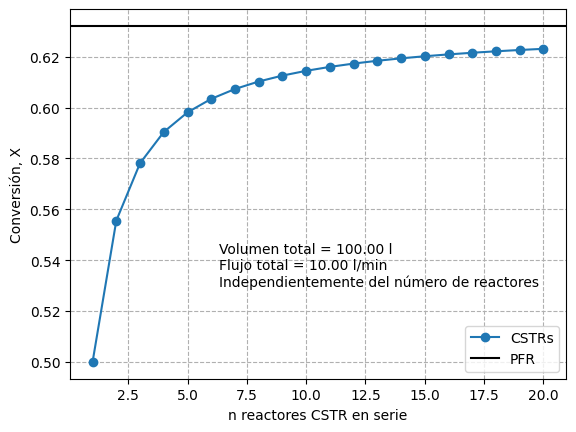

In [3]:
# Parameters
num_reactors = 20

ind_reactors = np.arange(1, num_reactors + 1)
X_reactors = []

for ind in ind_reactors:
    cstr_ind, cstr_X = cstr.cstrInSeriesX(
        ind,
        k,
        C_in,
        Q,
        V_total,
        order
    )
    X_reactors.append(cstr_X[-1])
X_reactors = np.array(X_reactors)

pfr_ind, pfr_X = pfr.pfrInSeriesX(
    1,
    k,
    C_in,
    Q,
    V_total,
    order
)

fig, ax = plt.subplots()
ax.plot(ind_reactors, X_reactors, marker='o', label='CSTRs')
ax.axhline(pfr_X[-1], color='k', label="PFR")
ax.set(
    xlabel="n reactores CSTR en serie",
    ylabel="Conversión, X",
)
n1 = f"Volumen total = {V_total:.2f} l \n"
n2 = f"Flujo total = {Q:.2f} l/min \n"
n3 = "Independientemente del número de reactores"
ax.annotate("".join([n1, n2, n3]), xy=(0.3, 0.25), xycoords='axes fraction')
ax.grid(ls='--')
ax.legend()
plt.show()

### CSTR en paralelo

Efecto del número de reactores CSTR en paralelo sobre la conversión total, para un volumen total de reactor(es) fijo:

- La conversión es la misma independientemente del número de reactores.

- Esto es porque al dividir el volumen y el flujo totales en $n$ reactores iguales con flujos iguales, el tiempo espacial será el mismo para todos los reactores.

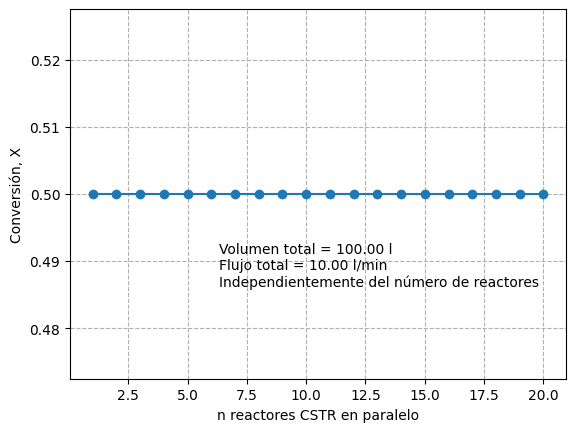

In [4]:
num_reactors = 20

cstr_ind, cstr_X = cstr.cstrInParallelX(
    num_reactors,
    k,
    C_in,
    Q,
    V_total,
    order
)


fig, ax = plt.subplots()
ax.plot(cstr_ind, cstr_X, marker='o')
ax.set(
    xlabel="n reactores CSTR en paralelo",
    ylabel="Conversión, X",
)
n1 = f"Volumen total = {V_total:.2f} l \n"
n2 = f"Flujo total = {Q:.2f} l/min \n"
n3 = "Independientemente del número de reactores"
ax.annotate("".join([n1, n2, n3]), xy=(0.3, 0.25), xycoords='axes fraction')
ax.grid(ls='--')
plt.show()

## Conversión PFR

### PFR en serie

Efecto del número de reactores PFR en serie sobre la conversión total, para un volumen total de reactor(es) fijo:

- La conversión lograda en $n$ reactores PFR es la misma que la lograda en un solo reactor PFR del mismo volumen.


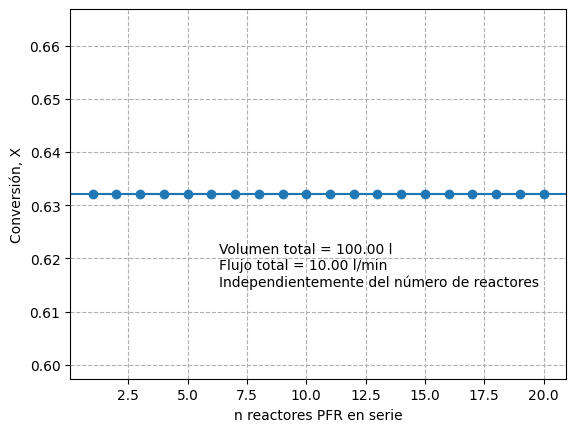

In [5]:
# Parameters
num_reactors = 20

ind_reactors = np.arange(1, num_reactors + 1)
X_reactors = []

for ind in ind_reactors:
    pfr_ind, pfr_X = pfr.pfrInSeriesX(
        num_reactors,
        k,
        C_in,
        Q,
        V_total,
        order
    )
    X_reactors.append(pfr_X[-1])
X_reactors = np.array(X_reactors)

pfr_ind, pfr_X = pfr.pfrInSeriesX(
    1,
    k,
    C_in,
    Q,
    V_total,
    order
)

fig, ax = plt.subplots()
ax.plot(ind_reactors, X_reactors, marker='o')
ax.axhline(pfr_X[-1])
ax.set(
    xlabel="n reactores PFR en serie",
    ylabel="Conversión, X",
)
n1 = f"Volumen total = {V_total:.2f} l \n"
n2 = f"Flujo total = {Q:.2f} l/min \n"
n3 = "Independientemente del número de reactores"
ax.annotate("".join([n1, n2, n3]), xy=(0.3, 0.25), xycoords='axes fraction')
ax.grid(ls='--')
plt.show()

### PFR en paralelo

Efecto del número de reactores PFR en paralelo sobre la conversión total, para un volumen total de reactor(es) fijo:

- La conversión lograda en $n$ reactores PFR es la misma que la lograda en un solo reactor PFR del mismo volumen.

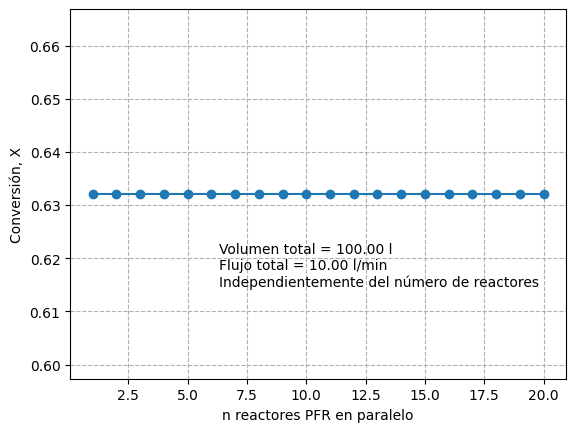

In [6]:
# Parameters
num_reactors = 20

pfr_ind, pfr_X = pfr.pfrInParallelX(
    num_reactors,
    k,
    C_in,
    Q,
    V_total,
    order
)


fig, ax = plt.subplots()
ax.plot(pfr_ind, pfr_X, marker='o')
ax.set(
    xlabel="n reactores PFR en paralelo",
    ylabel="Conversión, X",
)
n1 = f"Volumen total = {V_total:.2f} l \n"
n2 = f"Flujo total = {Q:.2f} l/min \n"
n3 = "Independientemente del número de reactores"
ax.annotate("".join([n1, n2, n3]), xy=(0.3, 0.25), xycoords='axes fraction')
ax.grid(ls='--')
plt.show()


## Perfiles a la salida de reactores CSTR/PFR en series

### arreglo de CSTR o de PFR en series

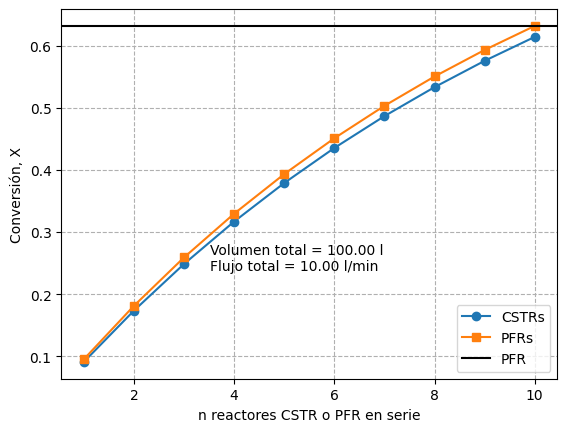

In [7]:
# Parameters
num_reactors = 10

cstr_ind, cstr_X = cstr.cstrInSeriesX(
    num_reactors,
    k,
    C_in,
    Q,
    V_total,
    order
)

pfr_ind, pfr_X = pfr.pfrInSeriesX(
    num_reactors,
    k,
    C_in,
    Q,
    V_total,
    order
)


fig, ax = plt.subplots()

ax.plot(cstr_ind[1:], cstr_X[1:], marker='o', label='CSTRs')
ax.plot(pfr_ind[1:], pfr_X[1:], marker='s', label='PFRs')
ax.axhline(pfr_X[-1], c='k', label='PFR')
ax.set(
    xlabel="n reactores CSTR o PFR en serie",
    ylabel="Conversión, X",
)
n1 = f"Volumen total = {V_total:.2f} l \n"
n2 = f"Flujo total = {Q:.2f} l/min \n"
n3 = ""
ax.annotate("".join([n1, n2, n3]), xy=(0.3, 0.25), xycoords='axes fraction')
ax.grid(ls='--')
ax.legend()
plt.show()

### arreglo CSTR/PFR en series (combinados)

In [8]:
#
num_cstrs = 1


# Referencias

- ***[Fogler, 2016]***: Fogler, H. S. (2016) Elements of Chemical Reaction Engineering (5th ed.). Prentice Education Inc.